# Importaciones Necesarias:

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lectura de los datos

In [111]:
datos = pd.read_csv('student_dropout_dataset_v3.csv')
drop_cols = ["Student_ID", "Dropout"]

X = datos.drop(columns=drop_cols)
y = datos['Dropout']

# Resumen de los datos

In [112]:
resumenEntrada = X.describe()
resumenSalida = y.describe()
print(resumenEntrada)
print(resumenSalida)

               Age  Family_Income  Study_Hours_per_Day  Attendance_Rate  \
count  10000.00000    9500.000000          9500.000000      10000.00000   
mean      21.02606   38377.247474             4.014592         81.73683   
std        2.13981   20496.232179             1.295450          8.22093   
min       17.00000   25000.000000             0.500000         38.20000   
25%       19.50000   25000.000000             3.160000         76.40000   
50%       21.00000   29740.500000             4.000000         81.80000   
75%       22.50000   44520.000000             4.870000         87.30000   
max       29.60000  316601.000000             8.980000        100.00000   

       Assignment_Delay_Days  Travel_Time_Minutes  Stress_Index           GPA  \
count           10000.000000          10000.00000   9500.000000  10000.000000   
mean                1.799700             30.17926      5.507147      2.308440   
std                 1.344307             11.91887      1.765951      1.061717   


# Gráficas para mostrar datos:

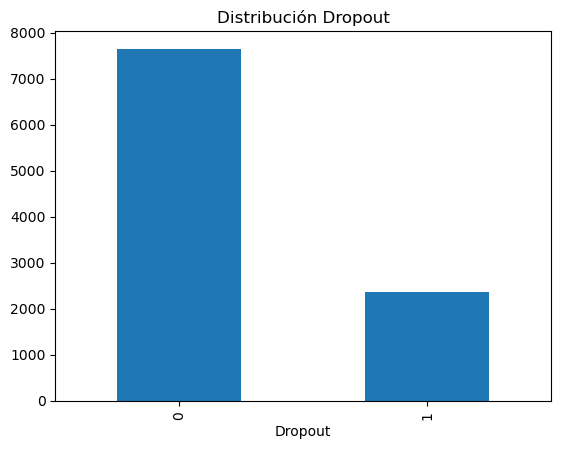

In [113]:
# Gráfica que muestra la distribución de dropout

y.value_counts().plot(kind="bar")
plt.title("Distribución Dropout")
plt.show()

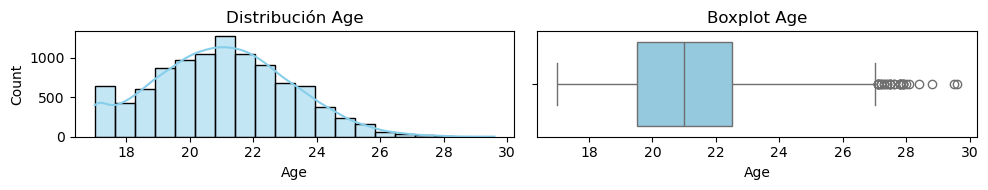

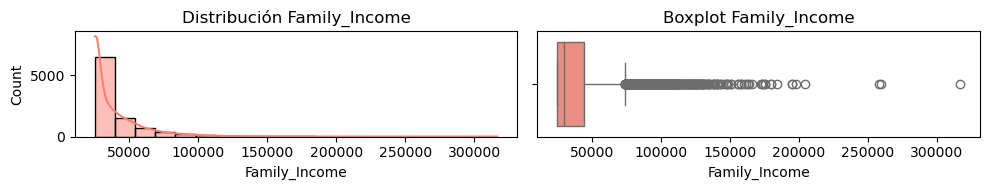

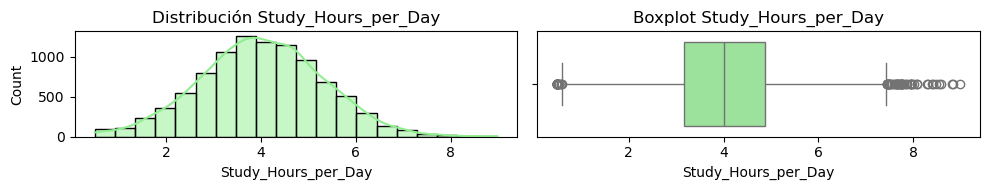

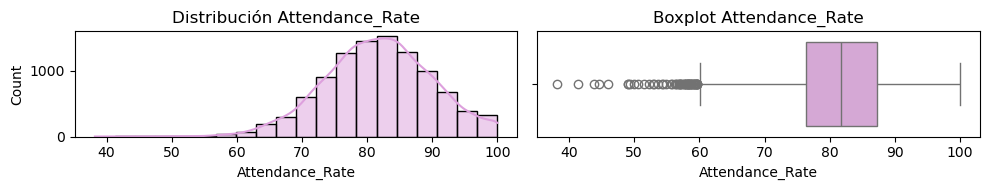

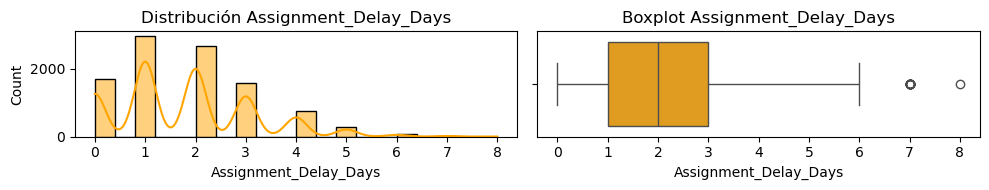

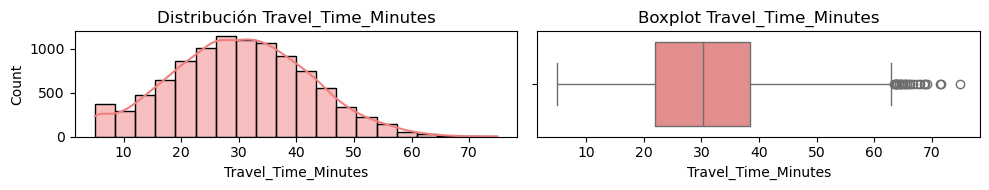

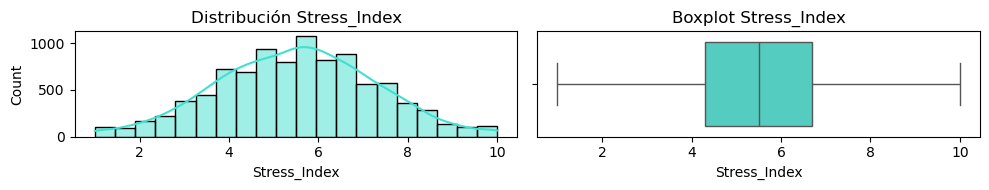

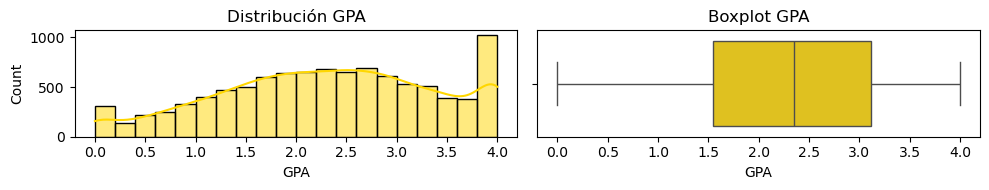

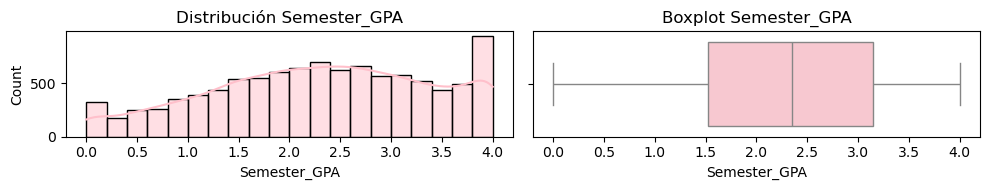

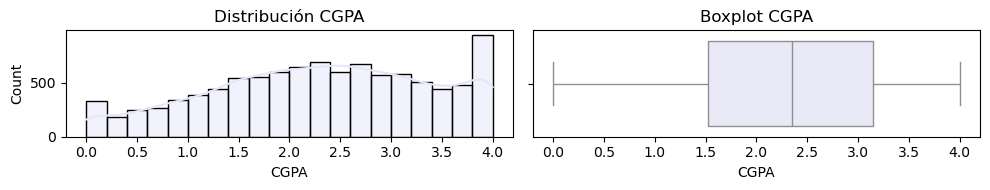

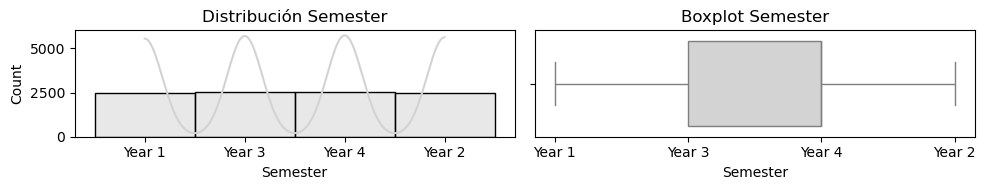

In [114]:
num_cols = ["Age", "Family_Income", "Study_Hours_per_Day", "Attendance_Rate", 
            "Assignment_Delay_Days", "Travel_Time_Minutes", "Stress_Index", 
            "GPA", "Semester_GPA", "CGPA", "Semester"]

colors = ["skyblue", "salmon", "lightgreen", "plum", "orange", 
          "lightcoral", "turquoise", "gold", "pink", "lavender", "lightgray"]

for col, color in zip(num_cols, colors):
    fig, axes = plt.subplots(1, 2, figsize=(10, 2))
    
    sns.histplot(data=X, x=col, bins=20, kde=True, color=color, ax=axes[0])
    axes[0].set_title(f"Distribución {col}")
    
    sns.boxplot(data=X, x=col, color=color, ax=axes[1])
    axes[1].set_title(f"Boxplot {col}")
    
    plt.tight_layout()
    plt.show()

# División de datos en conjuntos de entrenamiento , validación y test.

In [115]:
from sklearn.model_selection import train_test_split

# test es el 10% de los ejemplos, entranmiento es 80% y validación el resto.
X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size = 0.10, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_resto, y_resto, test_size = 0.20, stratify=y_resto, random_state=42)


# Detección y tratamiento de outliers:

In [116]:
# Importamos la clase TransformerMixin
from sklearn.base import TransformerMixin

# Creamos la clase de detección y tratamiento de Outliers
class OutlierDetecion_treatment_IQR(TransformerMixin):

    # Constructor de la clase
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # Método fit
    def fit(self, X, y=None):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        if self.columns is None:
            # Si no se determinan variables en el constructor si tratan todas
            self.columns = X.select_dtypes(include="number").columns
        self.stats = X[self.columns].describe()
        self.median = X[self.columns].median()

        # Devolvemos el propio objeto modificado
        return self

    # Método transform
    def transform(self, X):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Creamos una copia del DataFrame X para no perder los datos originales
        Xaux = X.copy()


        # Se comprueba qué elementos están por encima y por debajo de dichos límites (máscaras de booleanos)
        Q1 = self.stats.loc['25%']   
        Q3 = self.stats.loc['75%']
        IQRs = Q3 - Q1
        limiteInf = Q1 - self.k * IQRs
        limiteSup = Q3 + self.k * IQRs  
        menores = Xaux[self.columns] < limiteInf
        mayores = Xaux[self.columns] > limiteSup

        # Se recorren las variables para detectar outliers y tratarlos (sustituir por la mediana de la variable)
        for c in self.columns:
            # obtenemos la lista de booleanos correspondientes a si los valores de los ejemplos son outliers o no para la variable c
#             indices = <RELLENAR>
            indices = np.logical_or(menores[c],mayores[c])
            # Si hay outliers
            # <RELLENAR>
            if indices.any():
                Xaux.loc[indices,c] = self.median[c]
                # Los sustituimos por la mediana
                # <RELLENAR>
        # Se devuelve el DataFrame modificado
        return Xaux
    
    # Método para asignar los valores de los híper-parámetros y que, de este modo, 
        # podamos aplicar GridSearchCV sobre un objeto de esta clase
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
    def get_params(self, deep=True):
        # Devolvemos los valores de los híper-parámetros del método de preparación de datos
        return {"k": self.k}

In [117]:
out_IQR = OutlierDetecion_treatment_IQR(k=3)
out_IQR.fit(X_train)

# Test y Train sin Outliers

X_train_IQR = out_IQR.transform(X_train)
X_test_IQR = out_IQR.transform(X_test)

print(X_train_IQR.shape)
print(X_train.shape)

(7200, 17)
(7200, 17)


# Imputar valores perdidos en categoricas y numéricas:

In [122]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

columnas_numericas = list(X_train_IQR.select_dtypes(include="number").columns)
columnas_categoricas = list(X_train_IQR.select_dtypes(include="object").columns)

print(columnas_numericas)
print(columnas_categoricas)

# Aqui he utilizado un tipo de imputacion ( luego cuando tengamos el knn hecho se prueban diferentes para ver cual va mejor etc etc...)
imputer = ColumnTransformer(transformers=[("imp_numericas", SimpleImputer(strategy="mean"), columnas_numericas), 
                                          ("imp_categoricas", SimpleImputer(strategy="most_frequent"), columnas_categoricas)], remainder="passthrough")

imputer.fit(X_train_IQR)
X_train_imputado = imputer.transform(X_train_IQR)
X_test_imputado = imputer.transform(X_test_IQR)
cols_orden = columnas_numericas + columnas_categoricas
X_train_imputado = pd.DataFrame(X_train_imputado, columns=cols_orden, index=X_train_IQR.index)
X_test_imputado  = pd.DataFrame(X_test_imputado,  columns=cols_orden, index=X_test_IQR.index)

['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


# Pasar valores categoricos a numéricos:

In [124]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
# De momento solo pongo un tipo de encoder para probar!

encoder = ColumnTransformer(transformers=[("ohe", OneHotEncoder(),columnas_categoricas),],remainder="passthrough")
encoder.fit(X_train_imputado)
X_train_enc = encoder.transform(X_train_imputado)
X_test_enc  = encoder.transform(X_test_imputado)
print(X_train_enc)


[[1.0 0.0 1.0 ... 1.95 1.96 1.97]
 [1.0 0.0 0.0 ... 0.89 0.98 0.98]
 [0.0 1.0 0.0 ... 2.45 2.56 2.56]
 ...
 [0.0 1.0 0.0 ... 3.29 3.58 3.66]
 [0.0 1.0 0.0 ... 4.0 4.0 4.0]
 [1.0 0.0 0.0 ... 3.3 3.52 3.52]]
